# **QUESTION A1**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ikradurmus/CE555/blob/main/CE555_TermProject_datapreprocessing%20.ipynb)

In [1]:
#install and import required packages
!pip -q install geopandas pointpats libpysal esda

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from scipy.stats import chi2, norm

# 1. Read data
ufo = pd.read_csv("/content/drive/MyDrive/STAT623/ufo_sightings.csv")
ufo.head()

,Location.City,Location.State,Location.Country,Data.Shape,Data.Encounter duration,Data.Description excerpt,Location.Coordinates.Latitude,Location.Coordinates.Longitude,Dates.Sighted.Year,Dates.Sighted.Month,Date.Sighted.Day,Dates.Sighted.Hour,Dates.Sighted.Minute,Dates.Documented.Year,Dates.Documented.Month,Dates.Documented.Day
0,anchor point,AK,US,disk,300.0,Large UFO over Mt. ILIAMNA Alaska. ((NUFORC N...,59.776667,-151.831389,2005,5,24,18,30,2005,5,28
1,anchorage,AK,US,changing,21600.0,We could observe red lights dancing across the...,61.218056,-149.900278,2000,12,31,21,0,2001,2,18
2,anchorage,AK,US,changing,600.0,INTENSE AMBER-ORANGE HONEYCOMB SHAPED DUAL HOR...,61.218056,-149.900278,2006,10,23,21,3,2006,12,7
3,anchorage,AK,US,cigar,15.0,I explained away the first time I thought I se...,61.218056,-149.900278,2014,3,29,20,45,2014,4,4
4,anchorage,AK,US,circle,300.0,Orange circles &quot;climbing&quot; then fadin...,61.218056,-149.900278,2011,10,21,21,0,2011,10,25


In [2]:
#2 Understand data
print("Shape of dataset:")
print(ufo.shape)

print("\nColumn names:")
print(ufo.columns.tolist())

print("\nFirst 5 rows:")
print(ufo.head())

print("\nData types:")
print(ufo.dtypes)

print("\nMissing values by column:")
print(ufo.isna().sum())

Shape of dataset:
(60632, 16)

Column names:
['Location.City', 'Location.State', 'Location.Country', 'Data.Shape', 'Data.Encounter duration', 'Data.Description excerpt', 'Location.Coordinates.Latitude ', 'Location.Coordinates.Longitude ', 'Dates.Sighted.Year', 'Dates.Sighted.Month', 'Date.Sighted.Day', 'Dates.Sighted.Hour', 'Dates.Sighted.Minute', 'Dates.Documented.Year', 'Dates.Documented.Month', 'Dates.Documented.Day']

First 5 rows:
  Location.City Location.State Location.Country Data.Shape  \
0  anchor point             AK               US       disk   
1     anchorage             AK               US   changing   
2     anchorage             AK               US   changing   
3     anchorage             AK               US      cigar   
4     anchorage             AK               US     circle   

   Data.Encounter duration                           Data.Description excerpt  \
0                    300.0  Large UFO over Mt. ILIAMNA Alaska.  ((NUFORC N...   
1                  21600.

In [3]:
# 3. BASIC CLEANING
# Standardize column names if needed
ufo.columns = ufo.columns.str.strip()

# Create cleaned versions of key text fields
ufo["city_clean"] = ufo["Location.City"].astype(str).str.strip().str.lower()
ufo["state_clean"] = ufo["Location.State"].astype(str).str.strip().str.upper()
ufo["country_clean"] = ufo["Location.Country"].astype(str).str.strip().str.upper()

In [4]:
# 4. CHECK UNIQUE VALUES
# --------------------------------------------------
print("\nNumber of unique cities:", ufo["city_clean"].nunique())
print("Number of unique states:", ufo["state_clean"].nunique())
print("Number of unique countries:", ufo["country_clean"].nunique())
# 5. GROUP BY STATE
state_counts = (
    ufo.groupby("state_clean")
       .size()
       .reset_index(name="count")
       .sort_values("count", ascending=False)
       .reset_index(drop=True)
)

print(state_counts.head(20))
state_counts.to_csv("state_counts.csv", index=False)


Number of unique cities: 9149
Number of unique states: 51
Number of unique countries: 1
   state_clean  count
0           CA   8311
1           FL   3639
2           WA   3514
3           TX   3251
4           NY   2426
5           IL   2355
6           PA   2237
7           AZ   2232
8           OH   2169
9           MI   1734
10          NC   1671
11          OR   1588
12          MO   1350
13          CO   1321
14          IN   1231
15          VA   1214
16          MA   1206
17          NJ   1206
18          GA   1183
19          WI   1157


In [5]:
selected_state = "CA"

california_data = ufo[ufo["state_clean"] == selected_state].copy()

print("Selected state:", selected_state)
print("Number of California rows:", len(california_data))


Selected state: CA
Number of California rows: 8311


In [6]:
california_city_counts = (
    california_data.groupby("city_clean")
                   .size()
                   .reset_index(name="count")
                   .sort_values("count", ascending=False)
                   .reset_index(drop=True))

print(california_city_counts.head(20))

          city_clean  count
0        los angeles    343
1          san diego    324
2         sacramento    194
3           san jose    184
4      san francisco    179
5             fresno    104
6         long beach     76
7            burbank     75
8            modesto     75
9          riverside     72
10        santa rosa     71
11       bakersfield     69
12          el cajon     65
13  huntington beach     64
14     santa barbara     62
15           ventura     60
16            irvine     59
17           redding     54
18           hayward     53
19       simi valley     53


In [7]:
dup_mask = california_data.duplicated(
    subset=[
        "Location.City",
        "Location.State",
        "Location.Coordinates.Longitude",
        "Location.Coordinates.Latitude"
    ]
)

print("Any duplicates?:", dup_mask.any())
print("Number of duplicate rows:", dup_mask.sum())
print("Original number of California rows:", len(california_data))
print("Number after removing duplicates:", len(california_data) - dup_mask.sum())

Any duplicates?: True
Number of duplicate rows: 7425
Original number of California rows: 8311
Number after removing duplicates: 886


In [8]:
california_unique = california_data.drop_duplicates(
    subset=[
        "Location.City",
        "Location.State",
        "Location.Coordinates.Longitude",
        "Location.Coordinates.Latitude"
    ]
).copy()

print("Rows after duplicate removal:", len(california_unique))
california_unique.head()

Rows after duplicate removal: 886


,Location.City,Location.State,Location.Country,Data.Shape,Data.Encounter duration,Data.Description excerpt,Location.Coordinates.Latitude,Location.Coordinates.Longitude,Dates.Sighted.Year,Dates.Sighted.Month,Date.Sighted.Day,Dates.Sighted.Hour,Dates.Sighted.Minute,Dates.Documented.Year,Dates.Documented.Month,Dates.Documented.Day,city_clean,state_clean,country_clean
3664,acampo,CA,US,teardrop,3.0,An orange colored&#44 teardrop shaped object t...,38.174722,-121.277500,1998,9,25,20,0,1998,11,19,acampo,CA,US
3665,acton,CA,US,fireball,3.0,While driving westbound on I14 from Acton I sa...,34.470000,-118.195833,1999,9,11,22,16,1999,10,2,acton,CA,US
3670,adelanto,CA,US,light,60.0,Bright light moving fast but not a shooting star,34.582778,-117.408333,2011,8,30,21,0,2011,10,10,adelanto,CA,US
3674,agoura hills,CA,US,disk,300.0,Saucer shape w/lghts around rim that were in a...,34.136389,-118.773611,2007,9,11,17,30,2007,10,8,agoura hills,CA,US
3680,agua dulce,CA,US,egg,3.0,This is the second time in two weeks. Drivin...,34.496389,-118.324722,2005,12,22,19,10,2006,2,14,agua dulce,CA,US


In [9]:
before_counts = california_data["city_clean"].value_counts().sort_index()
after_counts = california_unique["city_clean"].value_counts().sort_index()

dup_summary = pd.DataFrame({
    "before": before_counts,
    "after": after_counts
}).fillna(0).astype(int)

dup_summary["removed"] = dup_summary["before"] - dup_summary["after"]

dup_summary.sort_values("removed", ascending=False).head(20)

,before,after,removed
city_clean,,,
los angeles,343,1,342
san diego,324,1,323
sacramento,194,1,193
san jose,184,1,183
san francisco,179,1,178
fresno,104,1,103
long beach,76,1,75
burbank,75,1,74
modesto,75,1,74


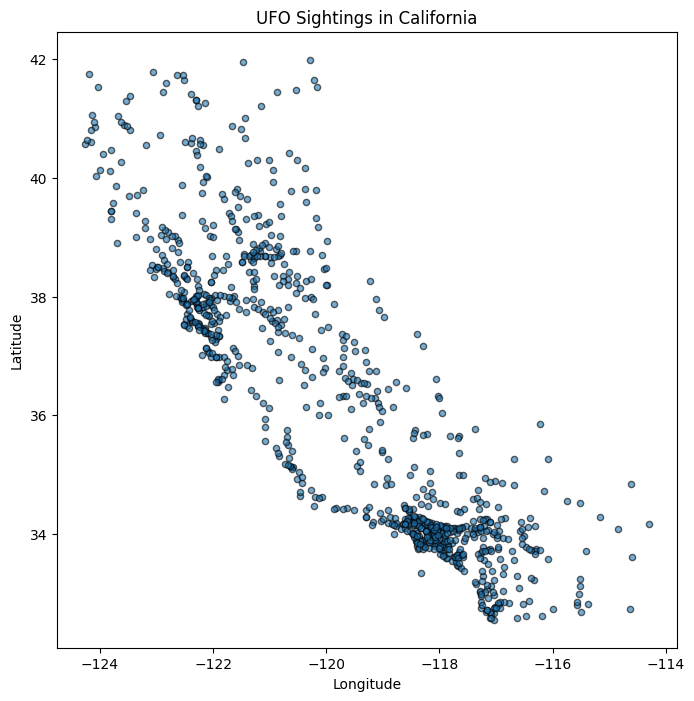

In [10]:
x = california_unique["Location.Coordinates.Longitude"].to_numpy()
y = california_unique["Location.Coordinates.Latitude"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x, y, s=20, alpha=0.6, edgecolor="black")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("UFO Sightings in California")

fig.savefig("california_points_map.png", dpi=300, bbox_inches="tight")
plt.show()

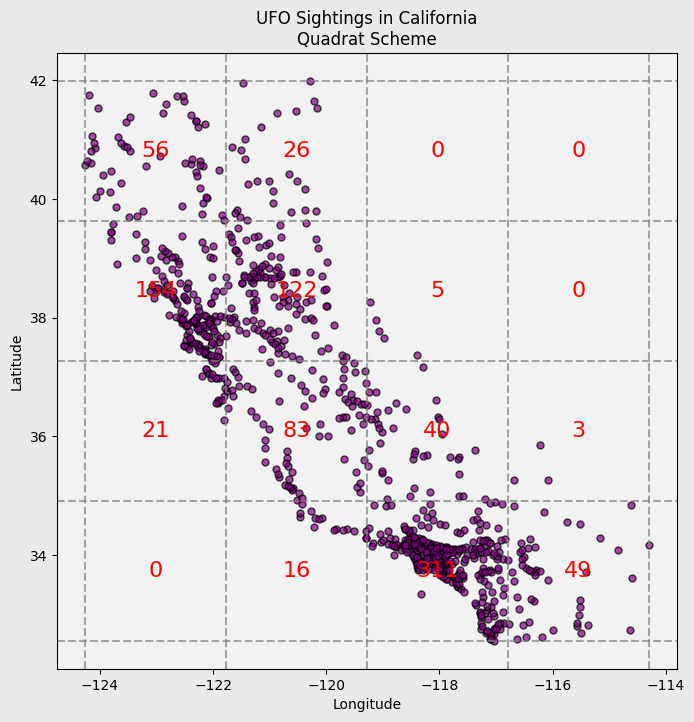

In [11]:
nx, ny = 4, 4

x_edges = np.linspace(x.min(), x.max(), nx + 1)
y_edges = np.linspace(y.min(), y.max(), ny + 1)

counts, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])

fig, ax = plt.subplots(figsize=(8, 8), facecolor="#eaeaea")
ax.set_facecolor("#f2f2f2")

ax.scatter(x, y, s=25, color="purple", alpha=0.7, edgecolor="black")

for xe in x_edges:
    ax.axvline(x=xe, color="gray", linestyle="--", alpha=0.7)

for ye in y_edges:
    ax.axhline(y=ye, color="gray", linestyle="--", alpha=0.7)

for i in range(nx):
    for j in range(ny):
        x_center = (x_edges[i] + x_edges[i+1]) / 2
        y_center = (y_edges[j] + y_edges[j+1]) / 2
        ax.text(
            x_center, y_center,
            str(int(counts[i, j])),
            color="red", fontsize=16,
            ha="center", va="center"
        )

ax.set_title("UFO Sightings in California\nQuadrat Scheme")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [12]:
quadrat_table = pd.DataFrame(
    counts.astype(int),
    index=[f"Row{i+1}" for i in range(ny)],
    columns=[f"Col{j+1}" for j in range(nx)]
)

quadrat_table

,Col1,Col2,Col3,Col4
Row1,0,21,154,56
Row2,16,83,122,26
Row3,311,40,5,0
Row4,49,3,0,0


In [13]:
# VARIANCE-TO-MEAN RATIO FOR QUADRAT COUNTS
quadrat_counts = counts.flatten()

mean_count = quadrat_counts.mean()
var_count = quadrat_counts.var(ddof=1)   # sample variance
vmr = var_count / mean_count

print("Quadrat counts:", quadrat_counts)
print("Mean:", mean_count)
print("Variance:", var_count)
print("Variance-to-Mean Ratio:", vmr)

Quadrat counts: [  0.  21. 154.  56.  16.  83. 122.  26. 311.  40.   5.   0.  49.   3.
   0.   0.]
Mean: 55.375
Variance: 6779.45
Variance-to-Mean Ratio: 122.42799097065462


In [14]:
if abs(vmr - 1) < 0.2:
    print("The variance-to-mean ratio is close to 1, which is broadly consistent with CSR.")
elif vmr > 1:
    print("The variance-to-mean ratio is greater than 1, suggesting clustering.")
else:
    print("The variance-to-mean ratio is less than 1, suggesting inhibition or regularity.")

The variance-to-mean ratio is greater than 1, suggesting clustering.


In [15]:
from scipy.spatial import distance_matrix

coords = np.column_stack((x, y))
D = distance_matrix(coords, coords)

np.fill_diagonal(D, np.inf)
nn_dist = D.min(axis=1)

print("Nearest-neighbor distances:")
print(nn_dist[:10])

print("Mean nearest-neighbor distance:", nn_dist.mean())
print("Median nearest-neighbor distance:", np.median(nn_dist))

Nearest-neighbor distances:
[0.04486257 0.13156262 0.07671093 0.03251303 0.13156262 0.12076946
 0.08559618 0.04883352 0.04309136 0.0292986 ]
Mean nearest-neighbor distance: 0.0880338006079239
Median nearest-neighbor distance: 0.06111138979667953


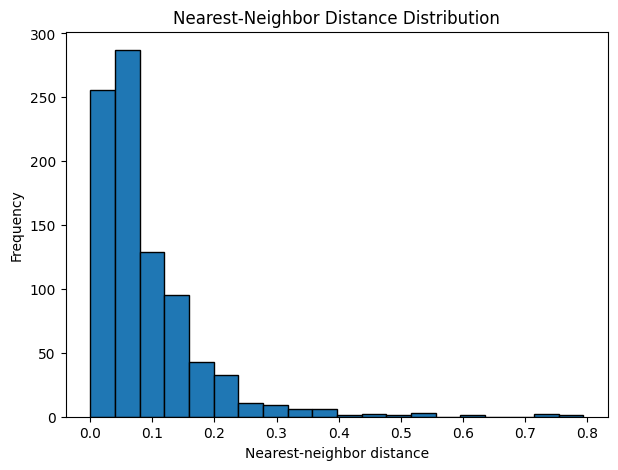

In [16]:
plt.figure(figsize=(7,5))
plt.hist(nn_dist, bins=20, edgecolor="black")
plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Frequency")
plt.title("Nearest-Neighbor Distance Distribution")
plt.show()

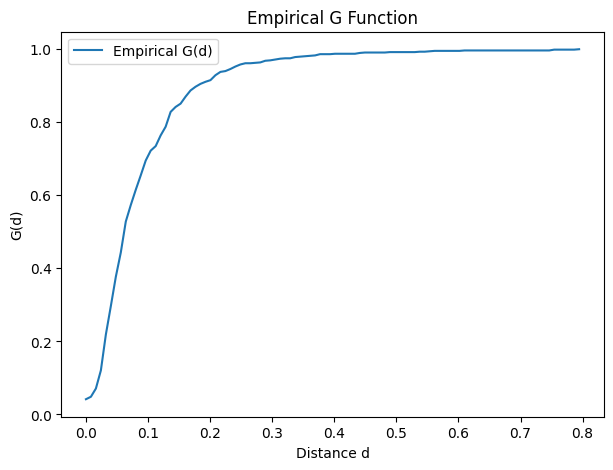

In [17]:
# Distribution function test-EMPIRICAL G FUNCTION
d_values = np.linspace(0, nn_dist.max(), 100)
G = np.array([(nn_dist <= d).mean() for d in d_values])

plt.figure(figsize=(7,5))
plt.plot(d_values, G, label="Empirical G(d)")
plt.xlabel("Distance d")
plt.ylabel("G(d)")
plt.title("Empirical G Function")
plt.legend()
plt.show()

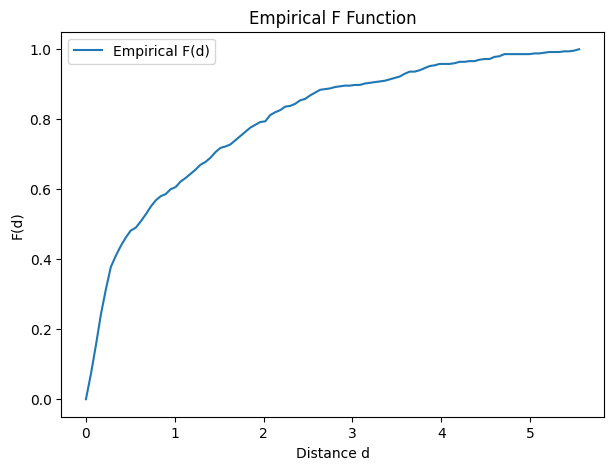

In [18]:
# Distribution function test-APPROXIMATE F FUNCTION
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

m = 500
rand_x = np.random.uniform(xmin, xmax, m)
rand_y = np.random.uniform(ymin, ymax, m)

random_pts = np.column_stack((rand_x, rand_y))
D_rf = distance_matrix(random_pts, coords)
f_dist = D_rf.min(axis=1)

d_values_f = np.linspace(0, max(f_dist.max(), nn_dist.max()), 100)
F = np.array([(f_dist <= d).mean() for d in d_values_f])

plt.figure(figsize=(7,5))
plt.plot(d_values_f, F, label="Empirical F(d)")
plt.xlabel("Distance d")
plt.ylabel("F(d)")
plt.title("Empirical F Function")
plt.legend()
plt.show()

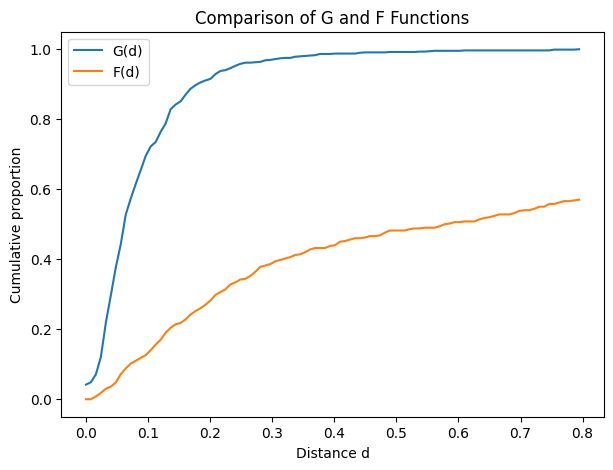

In [19]:
# Distribution function test-COMPARISON OF G AND F
d_common = np.linspace(0, min(nn_dist.max(), f_dist.max()), 100)
G_common = np.array([(nn_dist <= d).mean() for d in d_common])
F_common = np.array([(f_dist <= d).mean() for d in d_common])

plt.figure(figsize=(7,5))
plt.plot(d_common, G_common, label="G(d)")
plt.plot(d_common, F_common, label="F(d)")
plt.xlabel("Distance d")
plt.ylabel("Cumulative proportion")
plt.title("Comparison of G and F Functions")
plt.legend()
plt.show()

In [20]:
from scipy.spatial import distance_matrix
import numpy as np

# coordinates
x = california_unique["Location.Coordinates.Longitude"].to_numpy()
y = california_unique["Location.Coordinates.Latitude"].to_numpy()
coords = np.column_stack((x, y))

# STEP 1: Number of points
n = len(coords)
print("n =", n)
print()

# STEP 2: Study area
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
A = (xmax - xmin) * (ymax - ymin)

print("A = (xmax - xmin) * (ymax - ymin)")
print("A =", A)
print()

# STEP 3: Intensity
lam = n / A

print("λ = n / A")
print("λ =", lam)
print()


# STEP 4: Nearest neighbor distances
D = distance_matrix(coords, coords)
np.fill_diagonal(D, np.inf)
nn_dist = D.min(axis=1)
r_obs = nn_dist.mean()
print("r_obs = (1/n) * Σ d_i")
print("r_obs =", r_obs)
print()

# STEP 5: Expected distance under CSR
r_exp = 1 / (2 * np.sqrt(lam))

print("r_exp = 1 / (2 * sqrt(λ))")
print("r_exp =", r_exp)
print()

# STEP 6: Standard error
SE = 0.26136 / np.sqrt(n * lam)
print("SE = 0.26136 / sqrt(n * λ)")
print("SE =", SE)
print()

# STEP 7: Z statistic
Z = (r_obs - r_exp) / SE
print("Z =", Z)
print()


# STEP 8: Test
print("Step 8: Decision")
print("Compare |Z| with 1.96")

if abs(Z) > 1.96:
    print(f"|{Z:.2f}| > 1.96 → Reject H0")
else:
    print(f"|{Z:.2f}| < 1.96 → Fail to reject H0")

print()

# STEP 9: Interpretation
print("Step 9: Interpretation")
if Z < -1.96:
    print("Z is large negative → Clustering")
elif Z > 1.96:
    print("Z is large positive → Regularity (inhibition)")
else:
    print("Z is small → Consistent with CSR")

n = 886

A = (xmax - xmin) * (ymax - ymin)
A = 94.05430274749995

λ = n / A
λ = 9.42009003435572

r_obs = (1/n) * Σ d_i
r_obs = 0.0880338006079239

r_exp = 1 / (2 * sqrt(λ))
r_exp = 0.16290802459451018

SE = 0.26136 / sqrt(n * λ)
SE = 0.0028608476694163597

Z = -26.172041520079024

Step 8: Decision
Compare |Z| with 1.96
|-26.17| > 1.96 → Reject H0

Step 9: Interpretation
Z is large negative → Clustering


# **QUESTION A2**

In [21]:
#Load data and inspect
spruces = pd.read_csv("/content/drive/MyDrive/STAT623/spruces.csv")
spruces.head()

,x,y,diameter
0,2.4,1.4,0.21
1,1.9,3.3,0.25
2,0.7,14.4,0.28
3,2.1,17.2,0.23
4,2.5,25.1,0.25


In [22]:
#2 Understand data and check for missingness
print("Shape of dataset:")
print(spruces.shape)

print("\nColumn names:")
print(spruces.columns.tolist())

print("\nData types:")
print(spruces.dtypes)

print("\nMissing values by column:")
print(spruces.isna().sum())

Shape of dataset:
(134, 3)

Column names:
['x', 'y', 'diameter']

Data types:
x           float64
y           float64
diameter    float64
dtype: object

Missing values by column:
x           0
y           0
diameter    0
dtype: int64


In [23]:
#duplicate check
dup_mask = spruces.duplicated(subset=["x", "y"])

print("Any duplicate locations?:", dup_mask.any())
print("Number of duplicate rows:", dup_mask.sum())

Any duplicate locations?: False
Number of duplicate rows: 0


No duplicate or missing data exist the data is ready for use

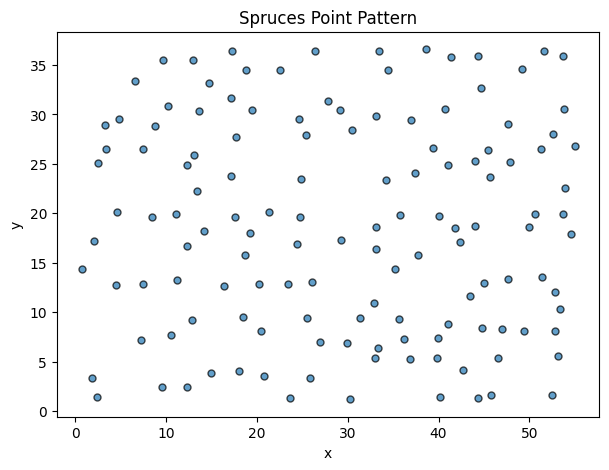

In [24]:
#plot the points
x = spruces["x"].to_numpy()
y = spruces["y"].to_numpy()

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=25, alpha=0.7, edgecolor="black")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spruces Point Pattern")
plt.show()

In [25]:
# a2 article b intensity calculation
n = len(spruces)

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

A = (xmax - xmin) * (ymax - ymin)
lam = n / A

print("Number of points (n):", n)
print("Study area (A):", A)
print("Intensity (λ):", lam)

Number of points (n): 134
Study area (A): 1922.2199999999998
Intensity (λ): 0.06971106324978411


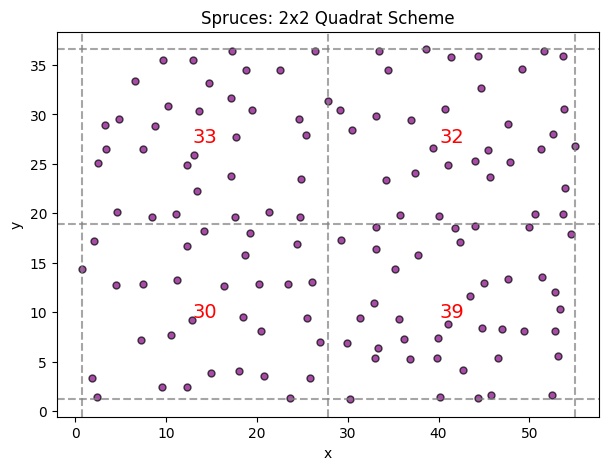

In [26]:
# A2b quadrat comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = spruces["x"].to_numpy()
y = spruces["y"].to_numpy()

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

nx1, ny1 = 2,2
x_edges1 = np.linspace(xmin, xmax, nx1 + 1)
y_edges1 = np.linspace(ymin, ymax, ny1 + 1)

counts1, _, _ = np.histogram2d(x, y, bins=[x_edges1, y_edges1])

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(x, y, s=25, color="purple", alpha=0.7, edgecolor="black")

for xe in x_edges1:
    ax.axvline(x=xe, color="gray", linestyle="--", alpha=0.7)
for ye in y_edges1:
    ax.axhline(y=ye, color="gray", linestyle="--", alpha=0.7)

for i in range(nx1):
    for j in range(ny1):
        xc = (x_edges1[i] + x_edges1[i+1]) / 2
        yc = (y_edges1[j] + y_edges1[j+1]) / 2
        ax.text(xc, yc, str(int(counts1[i, j])), color="red", fontsize=14,
                ha="center", va="center")

ax.set_title("Spruces: 2x2 Quadrat Scheme")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


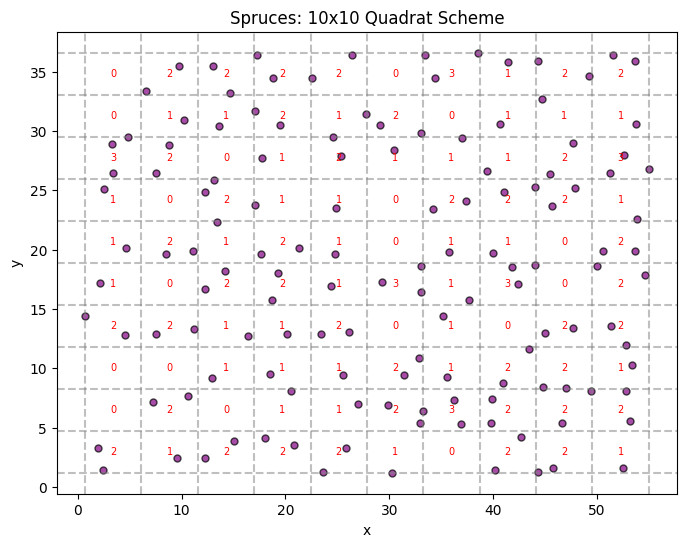

In [27]:
nx2, ny2 = 10, 10
x_edges2 = np.linspace(xmin, xmax, nx2 + 1)
y_edges2 = np.linspace(ymin, ymax, ny2 + 1)

counts2, _, _ = np.histogram2d(x, y, bins=[x_edges2, y_edges2])

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(x, y, s=25, color="purple", alpha=0.7, edgecolor="black")

for xe in x_edges2:
    ax.axvline(x=xe, color="gray", linestyle="--", alpha=0.5)
for ye in y_edges2:
    ax.axhline(y=ye, color="gray", linestyle="--", alpha=0.5)

for i in range(nx2):
    for j in range(ny2):
        xc = (x_edges2[i] + x_edges2[i+1]) / 2
        yc = (y_edges2[j] + y_edges2[j+1]) / 2
        ax.text(xc, yc, str(int(counts2[i, j])), color="red", fontsize=7,
                ha="center", va="center")

ax.set_title("Spruces: 10x10 Quadrat Scheme")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


PartB Question 3- Applying the tests-H 0​: Events follow CSR (Poisson process) H 1 : Events are not random (clustered or regular)

In [28]:
#Step 1 Quadrat counts

# coordinates
x = spruces["x"].to_numpy()
y = spruces["y"].to_numpy()

# 10x10 quadrat scheme
nx, ny = 10,10
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)

counts, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])

# flatten quadrat counts
quadrat_counts = counts.flatten().astype(int)

print("Quadrat counts:")
print(quadrat_counts)

Quadrat counts:
[2 0 0 2 1 1 1 3 0 0 1 2 0 2 0 2 0 2 1 2 2 0 1 1 2 1 2 0 1 2 2 1 1 1 2 2 1
 1 2 2 2 1 1 2 1 1 1 2 1 2 1 2 2 0 3 0 0 1 2 0 0 3 1 1 1 1 2 1 0 3 2 2 2 0
 3 1 2 1 1 1 2 2 2 2 0 0 2 2 1 2 1 2 1 2 2 2 1 3 1 2]


In [29]:
#Step 2: Mean Quadrat Count
m = len(quadrat_counts)
total_events = quadrat_counts.sum()
xbar = total_events / m
print("Total events =", total_events)
print("Number of quadrats (m) =", m)
print("X̄ = ΣXi / m")
print("X̄ =", xbar)

Total events = 134
Number of quadrats (m) = 100
X̄ = ΣXi / m
X̄ = 1.34


In [30]:
#Step 3: Sample Variance
s2 = quadrat_counts.var(ddof=1)
print("s² = Σ(Xi - X̄)² / (m - 1)")
print("s² =", s2)

s² = Σ(Xi - X̄)² / (m - 1)
s² = 0.7115151515151515


In [31]:
#Step 4: Index of Dispersion
I = s2 / xbar
print("I = s² / X̄")
print("I =", I)

I = s² / X̄
I = 0.5309814563545907


In [32]:
#Step 5: Test Statistic
chi2_stat = (m - 1) * I
print("Step 5: Test Statistic")
print("χ² = (m - 1) * s² / X̄")
print("χ² =", chi2_stat)

Step 5: Test Statistic
χ² = (m - 1) * s² / X̄
χ² = 52.56716417910448


In [33]:
df = m - 1
critical_value = chi2.ppf(0.95, df)
print("Degrees of freedom =", df)
print("Critical value (alpha = 0.05) =", critical_value) #95%

if chi2_stat > critical_value:
    print(f"Since {chi2_stat:.2f} > {critical_value:.2f}")
    print("Reject H0.")
else:
    print(f"Since {chi2_stat:.2f} < {critical_value:.2f}")
    print("Fail to reject H0.")

Degrees of freedom = 99
Critical value (alpha = 0.05) = 123.2252214533618
Since 52.57 < 123.23
Fail to reject H0.


In [34]:
#Clark evans test
from scipy.spatial import distance_matrix
coords = np.column_stack((x, y))
# Step 1: number of points
n = len(coords)
# Step 2: study area
A = (xmax - xmin) * (ymax - ymin)
# Step 3: intensity
lam = n / A
print("λ = n / A")
print("λ =", lam)
# Step 4: nearest-neighbor distances
D = distance_matrix(coords, coords)
np.fill_diagonal(D, np.inf)
nn_dist = D.min(axis=1)
r_obs = nn_dist.mean()
print("r_obs = (1/n) * Σ d_i")
print("r_obs =", r_obs)
# Step 5: expected distance under CSR
r_exp = 1 / (2 * np.sqrt(lam))
print("r_exp = 1 / (2 * sqrt(λ))")
print("r_exp =", r_exp)
# Step 6: standard error
SE = 0.26136 / np.sqrt(n * lam)
print("SE = 0.26136 / sqrt(n * λ)")
print("SE =", SE)
# Step 7: Z statistic
Z = (r_obs - r_exp) / SE
print("Observed mean NN distance:", r_obs)
print("Expected NN distance (CSR):", r_exp)
print("Z statistic:", Z)

λ = n / A
λ = 0.06971106324978411
r_obs = (1/n) * Σ d_i
r_obs = 2.5636697987869197
r_exp = 1 / (2 * sqrt(λ))
r_exp = 1.893734760541608
SE = 0.26136 / sqrt(n * λ)
SE = 0.0855137336801719
Observed mean NN distance: 2.5636697987869197
Expected NN distance (CSR): 1.893734760541608
Z statistic: 7.834239126441626


# **Part B: Continue on R**